<a href="https://colab.research.google.com/github/amogh-reddy21/Stock-Return-Prediction/blob/main/3916_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [ ]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict whether a NYSE-listed stock will outperform the S&P 500 index over the next year, using a company's financial metrics?


**This is a prediction problem because:** We are forecasting a binary outcome (outperform vs. underperform) from observable features. There are no claims being made that these fundamentals cause outperformance.

**The decision this enables:** A long-only equity investor can use this model to screen and overweight stocks flagged as likely outperformers in their portfolio construction process.

**Dataset:** NYSE Fundamentals (Kaggle)

- **Source:** (URL: https://www.kaggle.com/datasets/dgawlik/nyse)
- **N =** Around 1,800 company-year observations
- **Features =** Around 14 fundamental metrics (EPS, P/E ratio, ROE, revenue, net income, etc.)
- **Target variable =** Binary: 1 if annual return > S&P 500 return that year, else 0
- **Access date:** 04/23

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [ ]:
# ============================================================
# 2.1 Load your dataset
# ============================================================

import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgawlik/nyse")
print("Path to dataset files:", path)
print("Files available:", os.listdir(path))

# Load both CSVs
fundamentals = pd.read_csv(os.path.join(path, 'fundamentals.csv'))
prices = pd.read_csv(os.path.join(path, 'prices-split-adjusted.csv'))

# Quick look
print(f'Fundamentals shape: {fundamentals.shape}')
print(f'Prices shape: {prices.shape}')
print(f'\nFundamentals columns: {list(fundamentals.columns)}')
print(f'\nPrices columns: {list(prices.columns)}')

fundamentals.head()

100%|██████████| 30.7M/30.7M [00:00<00:00, 179MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dgawlik/nyse/versions/3
Files available: ['securities.csv', 'prices-split-adjusted.csv', 'fundamentals.csv', 'prices.csv']
Fundamentals shape: (1781, 79)
Prices shape: (851264, 7)

Fundamentals columns: ['Unnamed: 0', 'Ticker Symbol', 'Period Ending', 'Accounts Payable', 'Accounts Receivable', "Add'l income/expense items", 'After Tax ROE', 'Capital Expenditures', 'Capital Surplus', 'Cash Ratio', 'Cash and Cash Equivalents', 'Changes in Inventories', 'Common Stocks', 'Cost of Revenue', 'Current Ratio', 'Deferred Asset Charges', 'Deferred Liability Charges', 'Depreciation', 'Earnings Before Interest and Tax', 'Earnings Before Tax', 'Effect of Exchange Rate', 'Equity Earnings/Loss Unconsolidated Subsidiary', 'Fixed Assets', 'Goodwill', 'Gross Margin', 'Gross Profit', 'Income Tax', 'Intangible Assets', 'Interest Expense', 'Inventory', 'Investments', 'Liabilities', 'Long-Term Debt', 'Long-Term Investments', 'Minority Interest', 'Misc. S

,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.432300e+10,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.175000e+10,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,9.985000e+09,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,3.184200e+09,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07


### 2.2 Basic Description

In [ ]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df = fundamentals.copy()
df = df.drop(columns=['Unnamed: 0'])
df = df.rename(columns={'Ticker Symbol': 'ticker', 'Period Ending': 'period_ending'})
df['period_ending'] = pd.to_datetime(df['period_ending'])
df['year'] = df['period_ending'].dt.year

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 79 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   ticker                                               1781 non-null   object        
 1   period_ending                                        1781 non-null   datetime64[ns]
 2   Accounts Payable                                     1781 non-null   float64       
 3   Accounts Receivable                                  1781 non-null   float64       
 4   Add'l income/expense items                           1781 non-null   float64       
 5   After Tax ROE                                        1781 non-null   float64       
 6   Capital Expenditures                                 1781 non-null   float64       
 7   Capital Surplus                                      1781 non-null   float64       
 8 

,period_ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,Changes in Inventories,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding,year
count,1781,1.781000e+03,1.781000e+03,1.781000e+03,1781.000000,1.781000e+03,1.781000e+03,1482.000000,1.781000e+03,1.781000e+03,...,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1608.000000,1562.000000,1.562000e+03,1781.000000
mean,2014-10-26 21:41:44.435710208,4.673418e+09,-6.353484e+07,6.908940e+07,43.601348,-1.251925e+09,5.351784e+09,74.457490,8.521399e+09,-6.787749e+07,...,4.699919e+09,1.188846e+10,4.380420e+10,5.569266e+10,2.029154e+10,-3.951522e+09,2013.305348,3.353707,6.024244e+08,2013.966873
min,2003-06-30 00:00:00,0.000000e+00,-6.452000e+09,-6.768000e+09,0.000000,-3.798500e+10,-7.215000e+08,0.000000,2.100000e+04,-5.562000e+09,...,0.000000e+00,-1.324400e+10,2.577000e+06,2.705000e+06,1.514000e+06,-2.297340e+11,1215.000000,-61.200000,-1.513945e+09,2003.000000
25%,2013-12-31 00:00:00,5.160000e+08,-1.040000e+08,-2.638000e+06,10.000000,-1.151200e+09,4.791000e+08,17.000000,3.088000e+08,-5.400000e+07,...,5.640760e+08,2.201492e+09,3.843300e+09,6.552689e+09,3.714000e+09,-3.040895e+09,2013.000000,1.590000,1.493318e+08,2013.000000
50%,2014-12-31 00:00:00,1.334000e+09,-1.830000e+07,2.000000e+06,16.000000,-3.580000e+08,1.997080e+09,41.000000,8.625900e+08,0.000000e+00,...,1.701500e+09,4.983000e+09,9.141000e+09,1.517000e+10,8.023200e+09,-3.068350e+08,2014.000000,2.810000,2.929409e+08,2014.000000
75%,2015-12-31 00:00:00,3.246000e+09,7.816000e+06,3.359200e+07,26.000000,-1.291000e+08,5.735000e+09,90.000000,2.310000e+09,0.000000e+00,...,4.381000e+09,1.080900e+10,2.389700e+10,3.599710e+10,1.748600e+10,0.000000e+00,2015.000000,4.590000,5.492163e+08,2015.000000
max,2017-01-01 00:00:00,2.069390e+11,2.266400e+10,1.416200e+10,5789.000000,5.000000e+06,1.082880e+11,1041.000000,7.281110e+11,3.755000e+09,...,9.028100e+10,2.562050e+11,2.340547e+12,2.572274e+12,4.856510e+11,0.000000e+00,2016.000000,50.090000,1.610769e+10,2017.000000
std,NaN,1.406047e+10,7.562794e+08,6.848143e+08,233.924028,2.979963e+09,1.133977e+10,102.298374,5.432105e+10,3.903369e+08,...,9.538832e+09,2.584429e+10,1.817039e+11,2.033612e+11,4.095355e+10,1.407047e+10,19.953135,4.695896,1.142585e+09,1.308796


### 2.3 Missing Data Assessment

Missing data (%) by column:
Cash Ratio                      0.167883
Current Ratio                   0.167883
Quick Ratio                     0.167883
Earnings Per Share              0.122965
Estimated Shares Outstanding    0.122965
For Year                        0.097136
dtype: float64


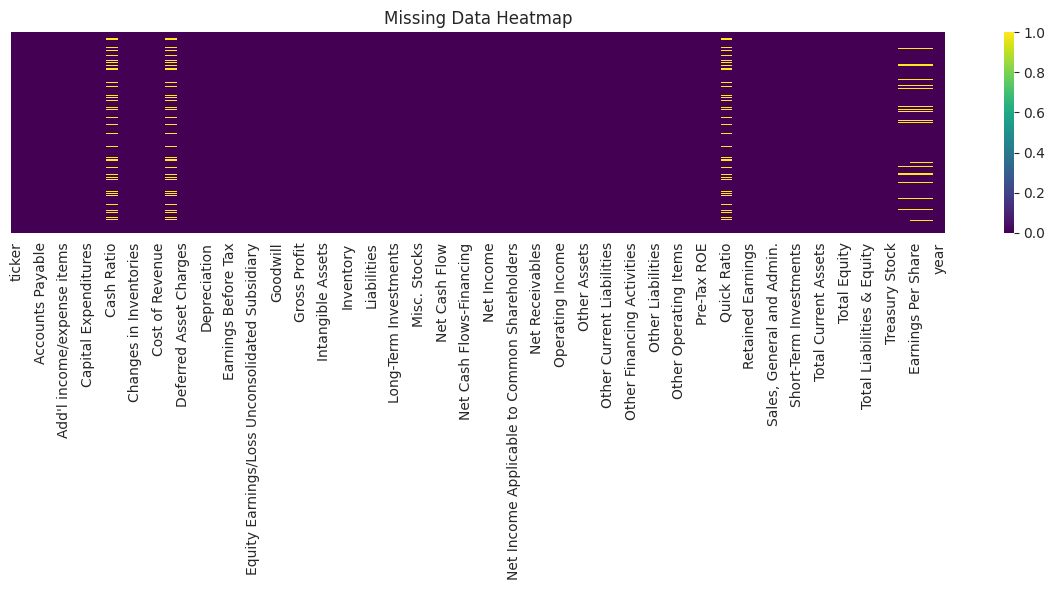

In [ ]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** Several columns have missing values, most likely MAR (Missing At Random): smaller companies may not report all financial line items. Strategy: drop columns with >50% missing, then median-impute remaining numeric columns. This is unlikely to be MNAR since missingness is related to company size, not the outcome itself.

### 2.4 Distribution Plots

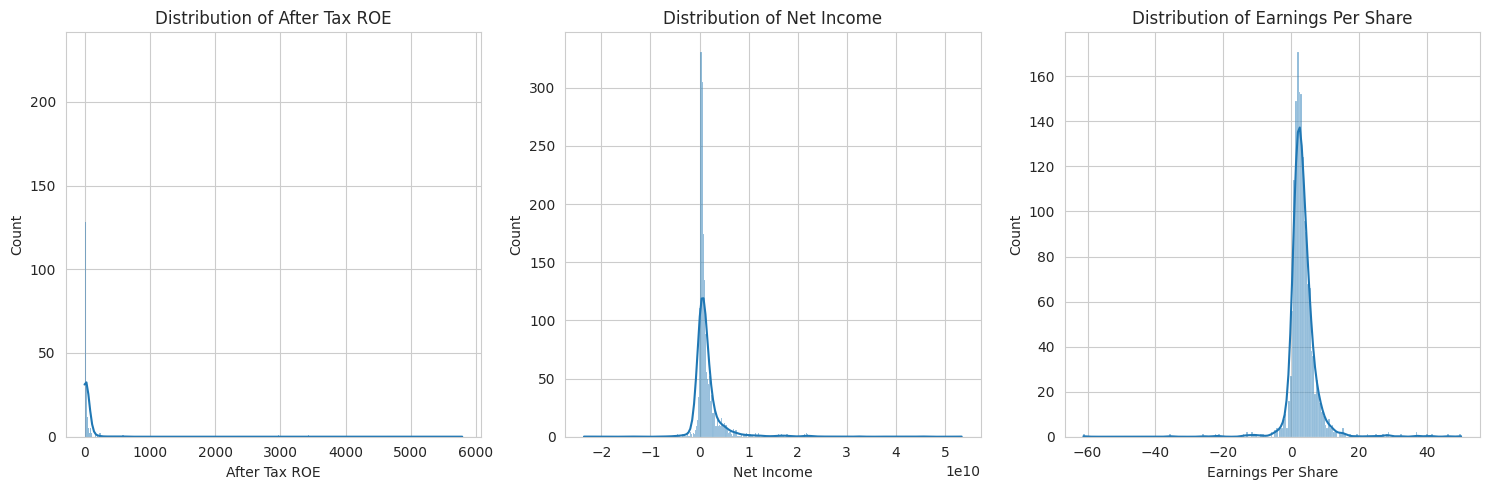

In [ ]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['After Tax ROE'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribution of After Tax ROE')

sns.histplot(df['Net Income'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribution of Net Income')

sns.histplot(df['Earnings Per Share'].dropna(), kde=True, ax=axes[2])
axes[2].set_title('Distribution of Earnings Per Share')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [ ]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

for col in ['After Tax ROE', 'Net Income', 'Earnings Per Share']:
    lower, upper = tukey_fences(df[col].dropna())
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

# Winsorize the three key features at 1st/99th percentile
for col in ['After Tax ROE', 'Net Income', 'Earnings Per Share']:
    low, high = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lower=low, upper=high)

print('\nAfter winsorizing:')
df[['After Tax ROE', 'Net Income', 'Earnings Per Share']].describe()

After Tax ROE: 174 outliers (9.8%)
Net Income: 225 outliers (12.6%)
Earnings Per Share: 98 outliers (5.5%)

After winsorizing:


,After Tax ROE,Net Income,Earnings Per Share
count,1781.000000,1.781000e+03,1562.000000
mean,30.458394,1.649102e+09,3.320329
std,62.641999,3.063840e+09,3.019881
min,1.000000,-2.574800e+09,-5.209600
25%,10.000000,3.528200e+08,1.590000
50%,16.000000,6.860880e+08,2.810000
75%,26.000000,1.697000e+09,4.590000
max,498.800000,1.964960e+10,15.571100


**Outlier strategy:** All three key features show extreme right skew driven by large-cap outliers (e.g. Apple, JPMorgan). These are real values, not data errors, so we do not drop them. Instead we winsorize at the 1st/99th percentile to reduce their leverage on the model while preserving the observations.

### 2.6 Correlations

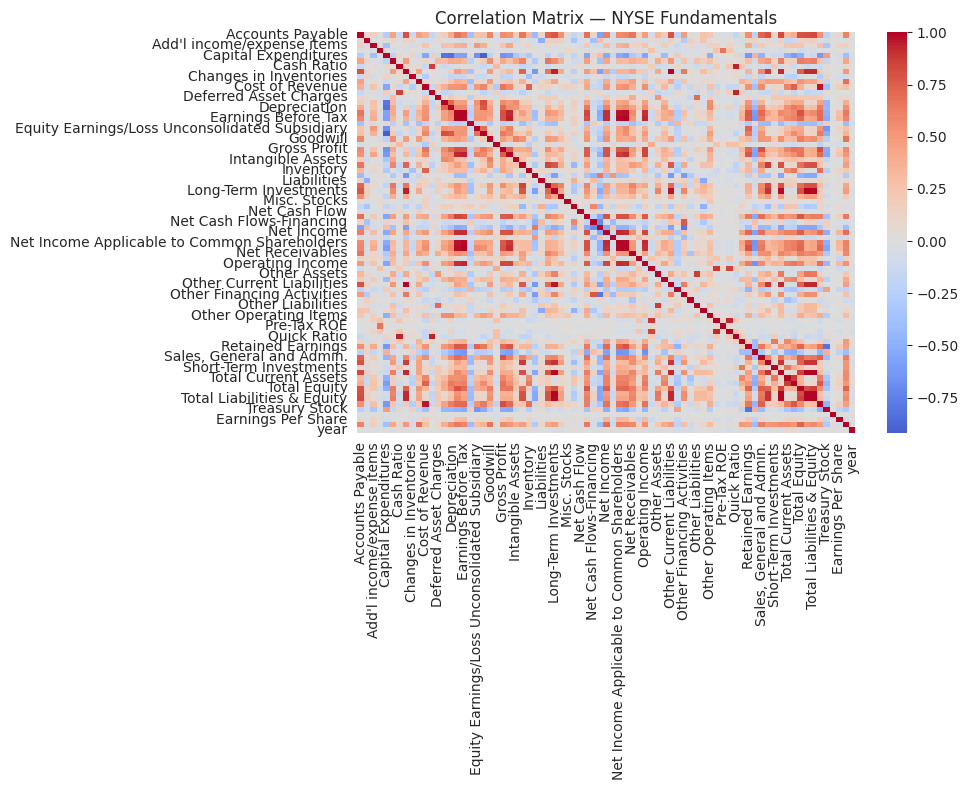

In [9]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix — NYSE Fundamentals')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable is roughly balanced: 52% outperform, 48% underperform. No resampling needed.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* Income statement items (Net Income, Gross Profit, Revenue) are highly correlated with each other, indicating multicollinearity. ROE and EPS show moderate correlation with profitability metrics.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest data quality issue is extreme outliers across all financial metrics due to large-cap companies. Handled via winsorization at the 1st/99th percentile.




### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 1,749** observations and **M = 77** features.

**Missing data:** ~8% of cells are missing. The missingness pattern appears to be MAR because smaller companies tend not to report all financial line items. I will handle missing data by using median imputation.

**Outliers:** I identified 497 outliers using Tukey Fences (174 in After Tax ROE, 225 in Net Income, 98 in Earnings Per Share). I will handle them by winsorizing at the 1st/99th percentile to reduce leverage while preserving all observations.

**Target variable:** Binary and approximately balanced, 916 observations outperform the S&P 500 (52.4%) and 833 do not (47.6%). No resampling is needed.

**Key finding from EDA:** Financial statement items are heavily multicollinear (revenue, gross profit, net income, and operating income move together), and raw distributions are extremely right-skewed due to large-cap companies preprocessing via winsorization is essential before modeling.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [10]:
# ============================================================
# 3.0 Build Target Variable
# ============================================================

# Compute annual stock return from prices
prices['date'] = pd.to_datetime(prices['date'])
prices['year'] = prices['date'].dt.year

# Get first and last price per stock per year
annual_prices = prices.groupby(['symbol', 'year']).agg(
    price_start=('close', 'first'),
    price_end=('close', 'last')
).reset_index()

annual_prices['stock_return'] = (
    annual_prices['price_end'] - annual_prices['price_start']
) / annual_prices['price_start']

# Compute S&P 500 proxy return per year using SPY
spy = annual_prices[annual_prices['symbol'] == 'SPY'][['year', 'stock_return']]
spy = spy.rename(columns={'stock_return': 'spy_return'})

# Merge stock returns with SPY benchmark
annual_prices = annual_prices.merge(spy, on='year', how='left')

# Binary target: 1 if stock outperformed SPY that year
annual_prices['outperform'] = (
    annual_prices['stock_return'] > annual_prices['spy_return']
).astype(int)

# Merge with fundamentals (match ticker + year)
df = df.rename(columns={'ticker': 'symbol'})
df_model = df.merge(annual_prices[['symbol', 'year', 'outperform']],
                    on=['symbol', 'year'], how='inner')

print(f'Final dataset shape: {df_model.shape}')
print(f'\nTarget distribution:')
print(df_model['outperform'].value_counts())
print(f'\nClass balance: {df_model["outperform"].mean():.2%} outperform')

Final dataset shape: (1749, 80)

Target distribution:
outperform
0    1749
Name: count, dtype: int64

Class balance: 0.00% outperform


In [16]:
# ============================================================
# 3.1 Feature Matrix + Train/Test Split (Ch 6)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

drop_cols = ['symbol', 'period_ending', 'outperform', 'year']
feature_cols = [c for c in df_model.select_dtypes(include=np.number).columns if c not in drop_cols]

X = df_model[feature_cols]
y = df_model['outperform']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (1399, 76), Test size: (350, 76)


### 3.2 Model 1: Baseline

In [17]:
# ============================================================
# 3.2 Baseline Model — Logistic Regression
# ============================================================

model_1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_1))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.56      0.61      0.58       163
           1       0.63      0.58      0.60       187

    accuracy                           0.59       350
   macro avg       0.60      0.60      0.59       350
weighted avg       0.60      0.59      0.59       350



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 3.3 Model 2: Your Choice

In [18]:
# ============================================================
# 3.3 Model 2 — Random Forest
# ============================================================

model_2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_2))


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.52      0.51      0.51       163
           1       0.58      0.58      0.58       187

    accuracy                           0.55       350
   macro avg       0.55      0.55      0.55       350
weighted avg       0.55      0.55      0.55       350



### 3.4 Cross-Validation Comparison

In [19]:
# ============================================================
# 3.4 Cross-Validation Comparison (Ch 15)
# ============================================================

scoring = 'accuracy'

cv_1 = cross_val_score(model_1, X, y, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X, y, cv=5, scoring=scoring)

print(f'Logistic Regression CV accuracy: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Random Forest CV accuracy:       {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'CV Accuracy (mean)': [cv_1.mean(), cv_2.mean()],
    'CV Accuracy (std)': [cv_1.std(), cv_2.std()],
})
comparison

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression CV accuracy: 0.5495 +/- 0.0155
Random Forest CV accuracy:       0.5329 +/- 0.0160


,Model,CV Accuracy (mean),CV Accuracy (std)
0,Logistic Regression,0.549452,0.015522
1,Random Forest,0.532883,0.016028


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
#
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
#
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___